In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
batter = pd.read_csv("./Datasets/batter.csv")
batter.head()

,batter,runs,avg,strike_rate
0,V Kohli,6634,36.251366,125.977972
1,S Dhawan,6244,34.882682,122.840842
2,DA Warner,5883,41.429577,136.401577
3,RG Sharma,5881,30.314433,126.964594
4,SK Raina,5536,32.374269,132.535312


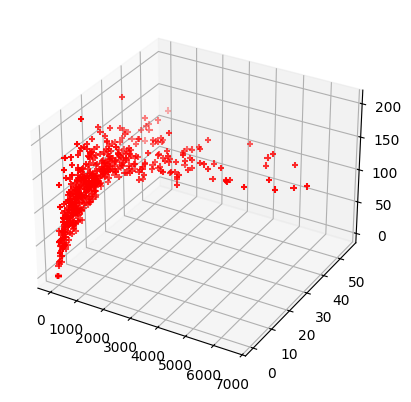

In [12]:
#For 3D Scatter Plots
fig = plt.figure() #Initialize empty figure
ax = plt.subplot(projection="3d") #Initialize empty 3d graph

ax.scatter3D(batter["runs"] , batter["avg"] , batter["strike_rate"] , color="red" , marker="+")


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

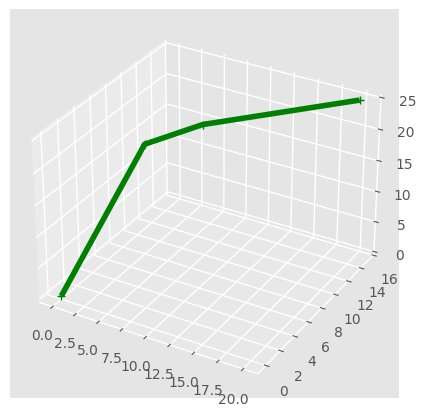

In [41]:
#For 3D Line Plots
plt.style.use("ggplot")
x = [0,1,5,20]
y = [0,10,13 , 15]
z = [0 , 15 , 17,25]

fig = plt.figure()
ax = plt.subplot(projection = "3d")
plot = ax.plot3D(x,y,z , marker="+" , color="green")
fig.colorbar(plot)

In [31]:
#About Mesh

x = np.array([1,2,3 , 4]) # a 1d arrry
y = np.array([4,5 , 6 , 7]) # a 1d array

# x contains 4 elements and y contains 4 elements too
#Mesh grid maps every coordinate of x and y like -> 1,4 1,5 1,6 ...
# then then mesh grid should be of size 4X4 
# xx contains x Locations only
#yy contains y locations only

xx , yy = (np.meshgrid(x,y)) 


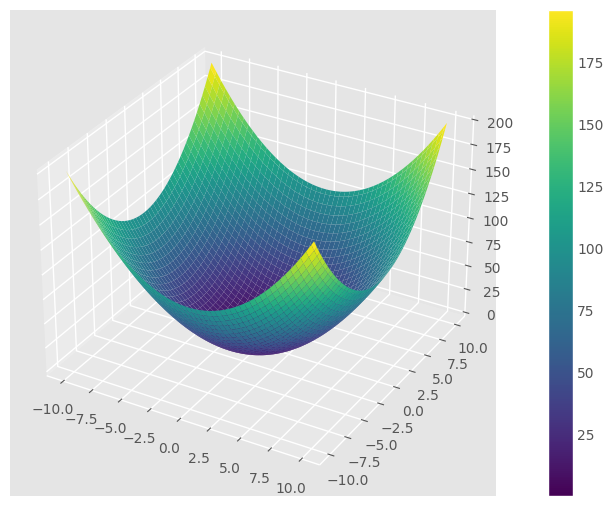

In [43]:
#For Surface Plots

x  = np.linspace(-10 , 10 , 100) # x = 1d array of 100 elements
y = np.linspace(-10 , 10 , 100) #y = 1d array of 100 elements

xx , yy = np.meshgrid(x , y) # xx and yy contains mesh grid 

z = xx**2 + yy ** 2 # compute x^2 + y^2

fig = plt.figure(figsize=(12,6))
ax = plt.subplot(projection = "3d")

plot = ax.plot_surface(xx , yy , z , cmap="viridis")
fig.colorbar(plot)
#Lower depth of plot , lower value of z and vice versa

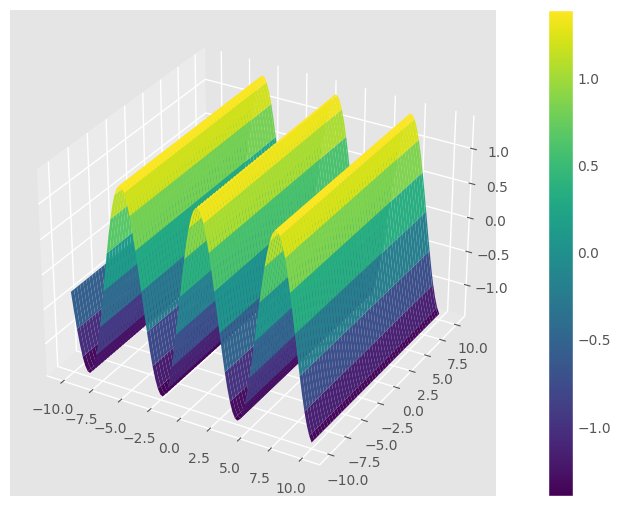

In [45]:
z = np.sin(xx) + np.cos(xx) # compute x^2 + y^2

fig = plt.figure(figsize=(12,6))
ax = plt.subplot(projection = "3d")

plot = ax.plot_surface(xx , yy , z , cmap="viridis")
fig.colorbar(plot)
#Lower depth of plot , lower value of z and vice versa

In [47]:
#Heatmaps

deliveries = pd.read_csv("./Datasets/IPL_Ball_by_Ball_2008_2022.csv")
deliveries.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals


In [63]:
# Filter out those which are more than ball 6 and batsman runs is 6
temp_df = deliveries[(deliveries["ballnumber"].isin([1,2,3,4,5,6])) & (deliveries["batsman_run"] == 6)]
temp_df.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
16,1312200,1,2,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,6,0,6,0,0,NaN,NaN,NaN,Rajasthan Royals
22,1312200,1,3,5,YBK Jaiswal,Yash Dayal,JC Buttler,NaN,6,0,6,0,0,NaN,NaN,NaN,Rajasthan Royals
103,1312200,1,17,2,TA Boult,R Sai Kishore,R Parag,NaN,6,0,6,0,0,NaN,NaN,NaN,Rajasthan Royals
107,1312200,1,17,6,OC McCoy,R Sai Kishore,R Parag,NaN,6,0,6,0,0,NaN,NaN,NaN,Rajasthan Royals
142,1312200,2,3,5,MS Wade,M Prasidh Krishna,Shubman Gill,NaN,6,0,6,0,0,NaN,NaN,NaN,Gujarat Titans


In [80]:
grid = temp_df.pivot_table(index="ballnumber" , columns="overs" , values="batsman_run" , aggfunc = "count")
grid

overs,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
ballnumber,,,,,,,,,,,,,,,,,,,,
1,9,31,75,60,71,77,34,59,86,54,82,91,87,101,90,102,107,126,118,136
2,17,40,62,74,76,102,56,62,83,62,92,72,109,101,124,120,115,142,114,120
3,31,49,70,74,112,63,49,73,79,86,83,87,79,99,103,129,111,137,151,151
4,39,56,72,103,80,86,59,70,81,61,69,79,100,97,100,121,100,151,132,151
5,33,58,58,74,81,78,64,69,73,74,72,87,100,90,86,113,120,117,138,116
6,27,54,76,71,72,80,38,56,52,67,70,70,84,88,106,96,101,129,128,148


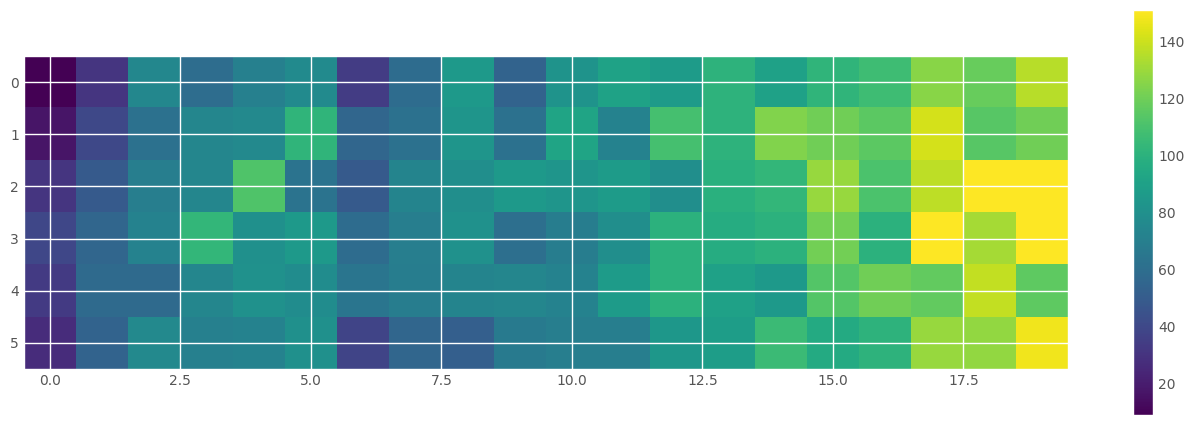

In [86]:
plt.figure(figsize=(15,5))
plt.imshow(grid)
plt.colorbar()